
# PCA-based Anomaly Detection untuk Early Warning System (EWS) Krisis Ekonomi
### Bagian Tugas: Principal Component Analysis (PCA) — Kelompok 4
**Mata Kuliah:** Data Mining — Politeknik Statistika STIS

---

**Konteks proyek kelompok:** Proposal kelompok membandingkan enam algoritma unsupervised
anomaly detection (Isolation Forest, LOF, Autoencoder, One-Class SVM, **PCA-based Anomaly
Detection**, dan DBSCAN) untuk mendeteksi kerentanan pra-krisis pada 16 indikator
makroekonomi dari 49 negara periode 1990–2024 (1.714 observasi setelah preprocessing).

**Catatan revisi metodologi (penting):**
Versi awal notebook ini melatih PCA dengan skema *train/validation/test* (70/15/15, mengikuti
pola Autoencoder), sehingga hasilnya **tidak bisa dibandingkan secara adil** dengan LOF —
LOF di-*scoring* pada seluruh 1.714 baris, sedangkan PCA versi lama hanya dievaluasi pada
subset test. Notebook ini memperbaikinya dengan skema berikut:

1. **StandardScaler dan PCA di-*fit* HANYA dari seluruh baris normal** (`crisis_label == 0`,
   1.385 baris) — *bukan* hanya 70%-nya. Prinsip "PCA hanya belajar dari kondisi normal" tetap
   terjaga, tidak ada informasi krisis yang bocor ke tahap pelatihan.
2. **SPE dan T² dihitung untuk SELURUH 1.714 baris** (normal + krisis), persis seperti cara LOF
   di-*scoring*.
3. **UCL (Upper Control Limit)** tetap dihitung **hanya dari sebaran SPE/T² data normal**,
   sehingga tidak ada label krisis yang bocor ke penentuan ambang batas anomali.

Dengan skema ini, metrik evaluasi (AUC-ROC, F1, dll.) PCA dapat dibandingkan langsung dengan
metrik LOF karena keduanya dihitung pada populasi observasi yang sama.



## 1. Import Library


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f as f_dist
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, confusion_matrix,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                      "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
ALPHA = 0.05                      # tingkat signifikansi UCL (95%)
EV_THRESHOLD = 0.95               # ambang cumulative explained variance

COLOR_NORMAL, COLOR_CRISIS, COLOR_UCL = "#4C72B0", "#C44E52", "#333333"



## 2. Memuat dan Mengeksplorasi Data

Dataset `data_cleaned.csv` berisi 1.714 observasi panel (49 negara × 1990–2024) dengan 14
indikator makroekonomi numerik yang telah distandardisasi Z-score pada tahap preprocessing
kelompok, ditambah kolom identifier (`economy`, `year`) dan label validasi eksternal
(`crisis_label`, 1 = periode krisis menurut katalog historis World Bank/IMF, 0 = normal).


In [2]:

df = pd.read_csv("../data/data_cleaned.csv")

FEATURE_COLS = [
    "GDP_Growth", "GDP_PerCapita_Growth", "Inflation_CPI", "Total_Reserves",
    "Unemployment", "Current_Account_GDP", "Trade_GDP", "FDI_Inflows_GDP",
    "Exports_GDP", "Imports_GDP", "Gross_Savings_GDP", "Exchange_Rate",
    "Manufacturing_Value", "Investment_GDP",
]
LABEL_COL = "crisis_label"

print("Dimensi data:", df.shape)
print("\nDistribusi crisis_label:")
print(df[LABEL_COL].value_counts())
df.head()


Dimensi data: (1714, 17)

Distribusi crisis_label:
crisis_label
0    1385
1     329
Name: count, dtype: int64


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,crisis_label
0,ARE,1990,2.690913,2.607447,-0.035597,-0.349079,-1.105892,2.12939,0.234573,-0.486899,0.326385,0.123081,1.10385,-0.224663,-1.589531,-0.270213,0
1,ARE,1991,-0.638363,-1.838101,-0.035597,-0.347005,-1.105892,2.12939,0.234573,-0.448764,0.326385,0.123081,1.10385,-0.224663,-1.601884,-0.270213,0
2,ARE,1992,0.032110,-1.108947,-0.035597,-0.346099,-1.087378,2.12939,0.234573,-0.422930,0.326385,0.123081,1.10385,-0.224663,-1.573871,-0.270213,0
3,ARE,1993,-0.530135,-1.574741,-0.035597,-0.344897,-1.047336,2.12939,0.234573,-0.356948,0.326385,0.123081,1.10385,-0.224663,-1.528502,-0.270213,0
4,ARE,1994,0.990307,-0.018863,-0.035597,-0.343393,-1.061760,2.12939,0.234573,-0.441240,0.326385,0.123081,1.10385,-0.224663,-1.747591,-0.270213,0



## 3. Memisahkan Data Normal vs Krisis, lalu Standardisasi

**Poin krusial (perbaikan metodologi):** `StandardScaler` di-*fit* hanya dari baris normal
(1.385 baris), lalu dipakai untuk men-*transform* SELURUH data (normal + krisis). Ini konsisten
dengan prinsip "profil normal" pada seluruh metode unsupervised di proyek ini — model tidak
boleh "melihat" pola krisis saat belajar mendefinisikan kondisi normal.


In [3]:

normal_mask = df[LABEL_COL] == 0
X_normal_raw = df.loc[normal_mask, FEATURE_COLS].values
n_normal = X_normal_raw.shape[0]
print(f"Jumlah baris normal yang dipakai untuk fit scaler & PCA: {n_normal}")

scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal_raw)          # fit HANYA dari normal

X_all_scaled = scaler.transform(df[FEATURE_COLS].values)      # transform SEMUA baris
print("Bentuk X_all_scaled:", X_all_scaled.shape)


Jumlah baris normal yang dipakai untuk fit scaler & PCA: 1385
Bentuk X_all_scaled: (1714, 14)



## 4. PCA — Landasan Teori Singkat

PCA sebagai metode deteksi anomali (proposal Bab 2.1.3.5) bekerja atas premis bahwa data normal
berada dekat manifold linear berdimensi rendah yang dibentuk oleh komponen utama dengan
varians tinggi, sementara anomali memiliki komponen residual signifikan di luar manifold
tersebut. Tahapannya:

1. Proyeksikan data ke ruang komponen utama menggunakan matriks *eigenvector* $\mathbf{P}$.
2. Rekonstruksi kembali ke ruang asli menggunakan hanya $k$ komponen utama pertama.
3. Ukur **reconstruction error** (*Squared Prediction Error*, SPE / Q-statistic).
4. Ukur **Hotelling's T²** sebagai jarak dalam ruang PC tereduksi.

Jumlah komponen $k$ dipilih dari kriteria *cumulative explained variance* ≥ 95%, mengikuti
proposal Bab 3.2.6. PCA di-*fit* penuh (semua 14 komponen) terlebih dahulu agar *eigenvalue*
komponen yang dibuang tetap tersedia — dibutuhkan untuk formula UCL SPE pada bagian berikut.


In [4]:

pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_normal_scaled)              # PCA di-fit HANYA dari data normal

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.searchsorted(cum_var, EV_THRESHOLD) + 1)
k = min(k, len(cum_var))

print(f"Jumlah komponen utama (k) untuk >= {EV_THRESHOLD*100:.0f}% cumulative explained variance: {k}")
print(f"Cumulative explained variance pada k={k}: {cum_var[k-1]*100:.2f}%")


Jumlah komponen utama (k) untuk >= 95% cumulative explained variance: 9
Cumulative explained variance pada k=9: 95.41%



### 4.1 Scree Plot

Scree plot menampilkan proporsi varians yang dijelaskan tiap komponen (bar) dan akumulasinya
(garis), membantu memvisualisasikan titik potong $k$ yang dipilih.


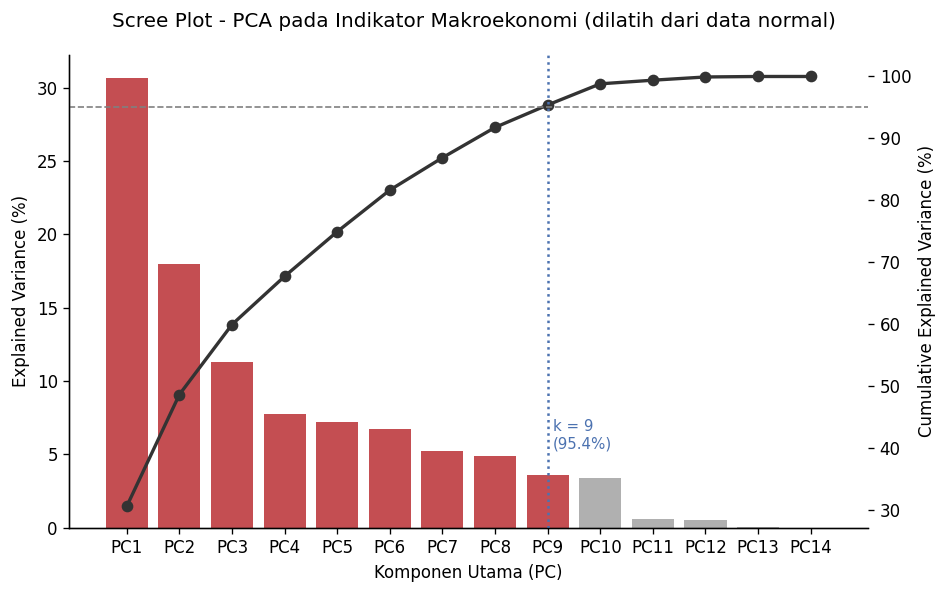

In [5]:

p = len(FEATURE_COLS)
x = np.arange(1, p + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(x, pca_full.explained_variance_ratio_ * 100,
        color=[COLOR_CRISIS if i < k else "#B0B0B0" for i in range(p)])
ax1.set_xlabel("Komponen Utama (PC)")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_xticks(x); ax1.set_xticklabels([f"PC{i}" for i in x])

ax2 = ax1.twinx()
ax2.plot(x, cum_var * 100, color=COLOR_UCL, marker="o", linewidth=2)
ax2.axhline(95, color="gray", linestyle="--", linewidth=1)
ax2.axvline(k, color=COLOR_NORMAL, linestyle=":", linewidth=1.5)
ax2.set_ylabel("Cumulative Explained Variance (%)")
ax2.text(k + 0.1, 40, f"k = {k}\n({cum_var[k-1]*100:.1f}%)", color=COLOR_NORMAL, fontsize=9)

fig.suptitle("Scree Plot - PCA pada Indikator Makroekonomi (dilatih dari data normal)")
fig.tight_layout()
plt.show()



## 5. Menghitung SPE (Q-statistic) dan Hotelling's T²

Untuk $k$ komponen yang dipertahankan:

$$\text{SPE}_i = \sum_{j=1}^{p} (x_{ij} - \hat{x}_{ij})^2, \qquad
\hat{\mathbf{x}}_i = \mathbf{t}_i \mathbf{P}_k^\top, \qquad \mathbf{t}_i = \mathbf{x}_i \mathbf{P}_k$$

$$T^2_i = \sum_{j=1}^{k} \frac{t_{ij}^2}{\lambda_j}$$

dengan $\lambda_j$ adalah *eigenvalue* (varians) komponen ke-$j$ dari PCA yang dilatih pada data
normal. **Kedua statistik ini dihitung untuk seluruh 1.714 baris** (normal + krisis), sesuai
perbaikan metodologi pada bagian pendahuluan.


In [6]:

components_k = pca_full.components_[:k]           # (k, p)
eigenvalues_k = pca_full.explained_variance_[:k]   # (k,)

scores_all = X_all_scaled @ components_k.T         # skor PC untuk SEMUA baris
X_reconstructed = scores_all @ components_k
residual_all = X_all_scaled - X_reconstructed

SPE = np.sum(residual_all ** 2, axis=1)
T2 = np.sum((scores_all ** 2) / eigenvalues_k, axis=1)

df["SPE"] = SPE
df["T2"] = T2
df[["economy", "year", "crisis_label", "SPE", "T2"]].head()


,economy,year,crisis_label,SPE,T2
0,ARE,1990,0,0.261251,27.876806
1,ARE,1991,0,0.899238,11.358071
2,ARE,1992,0,0.652306,9.501082
3,ARE,1993,0,0.707359,10.139548
4,ARE,1994,0,0.332566,11.582002



## 6. Upper Control Limit (UCL) — Dihitung Hanya dari Data Normal

- **UCL SPE**: pendekatan chi-square (Jackson & Mudholkar, 1979) menggunakan *eigenvalue*
  komponen yang **dibuang** ($\lambda_{k+1}, \dots, \lambda_p$) dari PCA yang dilatih pada data
  normal:

$$\text{UCL}_{\text{SPE}} = \theta_1 \left[ \frac{c_\alpha \sqrt{2\theta_2 h_0^2}}{\theta_1} + 1 +
\frac{\theta_2 h_0 (h_0 - 1)}{\theta_1^2} \right]^{1/h_0}, \quad
\theta_i = \sum_{j=k+1}^{p} \lambda_j^i, \quad
h_0 = 1 - \frac{2\theta_1\theta_3}{3\theta_2^2}$$

- **UCL T²**: distribusi F, dengan $n$ = jumlah data **normal** yang dipakai melatih PCA (1.385,
  bukan seluruh dataset):

$$\text{UCL}_{T^2} = \frac{k(n-1)(n+1)}{n(n-k)}\, F_{\alpha, k, n-k}$$

Karena kedua UCL ini murni fungsi dari sebaran statistik pada data **normal**, tidak ada
informasi label krisis yang bocor ke penentuan ambang batas anomali.


In [7]:

def spe_ucl_jackson_mudholkar(eigenvalues_all, k, alpha=ALPHA):
    lambdas_discarded = eigenvalues_all[k:]
    if len(lambdas_discarded) == 0:
        return 0.0
    theta1 = np.sum(lambdas_discarded)
    theta2 = np.sum(lambdas_discarded ** 2)
    theta3 = np.sum(lambdas_discarded ** 3)
    if theta1 == 0:
        return 0.0
    h0 = 1 - (2 * theta1 * theta3) / (3 * theta2 ** 2) if theta2 != 0 else 1.0
    c_alpha = norm.ppf(1 - alpha)
    term = (c_alpha * np.sqrt(2 * theta2 * h0 ** 2) / theta1) + 1 + \
           (theta2 * h0 * (h0 - 1) / theta1 ** 2)
    return float(theta1 * (term ** (1.0 / h0)))


def t2_ucl_f_distribution(k, n, alpha=ALPHA):
    f_crit = f_dist.ppf(1 - alpha, k, n - k)
    return float((k * (n - 1) * (n + 1)) / (n * (n - k)) * f_crit)


UCL_SPE = spe_ucl_jackson_mudholkar(pca_full.explained_variance_, k, ALPHA)
UCL_T2 = t2_ucl_f_distribution(k, n_normal, ALPHA)

print(f"UCL SPE (alpha={ALPHA}) : {UCL_SPE:.4f}")
print(f"UCL T^2 (alpha={ALPHA}) : {UCL_T2:.4f}")

df["is_anomaly_SPE"] = (df["SPE"] > UCL_SPE).astype(int)
df["is_anomaly_T2"] = (df["T2"] > UCL_T2).astype(int)
df["is_anomaly_combined"] = ((df["is_anomaly_SPE"] == 1) | (df["is_anomaly_T2"] == 1)).astype(int)
df["combined_score"] = np.maximum(df["SPE"] / UCL_SPE, df["T2"] / UCL_T2)

print("\nJumlah anomali terdeteksi (gabungan SPE atau T2):", df["is_anomaly_combined"].sum())
pd.crosstab(df["crisis_label"], df["is_anomaly_combined"],
            rownames=["crisis_label"], colnames=["is_anomaly_combined"])


UCL SPE (alpha=0.05) : 2.0618
UCL T^2 (alpha=0.05) : 17.0911

Jumlah anomali terdeteksi (gabungan SPE atau T2): 336


is_anomaly_combined,0,1
crisis_label,,
0,1169,216
1,209,120



## 7. Control Chart

Control chart memplot SPE dan T² untuk setiap observasi (diurutkan sesuai indeks panel data),
diwarnai berdasarkan `crisis_label`, dengan garis UCL sebagai ambang batas anomali. Titik krisis
yang berada jauh di atas UCL mengindikasikan bahwa PCA berhasil menangkap sinyal pra-krisis;
titik krisis di bawah UCL merupakan *false negative* deteksi.


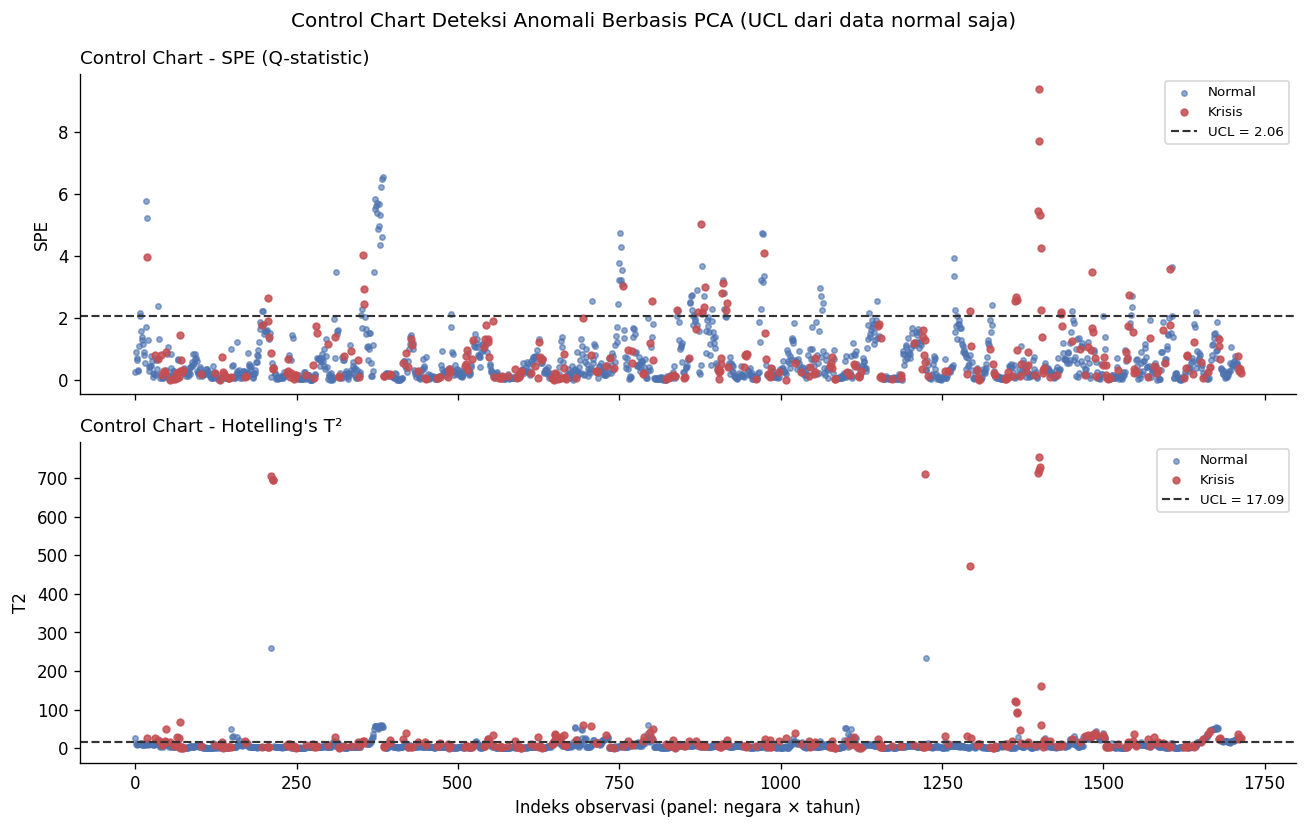

In [8]:

df_plot = df.reset_index(drop=True)
df_plot["idx"] = np.arange(len(df_plot))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, col, ucl, title in [
    (axes[0], "SPE", UCL_SPE, "Control Chart - SPE (Q-statistic)"),
    (axes[1], "T2", UCL_T2, "Control Chart - Hotelling's T\u00b2"),
]:
    nmask = df_plot["crisis_label"] == 0
    cmask = df_plot["crisis_label"] == 1
    ax.scatter(df_plot.loc[nmask, "idx"], df_plot.loc[nmask, col],
               s=10, color=COLOR_NORMAL, alpha=0.6, label="Normal")
    ax.scatter(df_plot.loc[cmask, "idx"], df_plot.loc[cmask, col],
               s=16, color=COLOR_CRISIS, alpha=0.85, label="Krisis")
    ax.axhline(ucl, color=COLOR_UCL, linestyle="--", linewidth=1.3,
               label=f"UCL = {ucl:.2f}")
    ax.set_ylabel(col); ax.set_title(title, fontsize=11, loc="left")
    ax.legend(loc="upper right", fontsize=8)

axes[1].set_xlabel("Indeks observasi (panel: negara \u00d7 tahun)")
fig.suptitle("Control Chart Deteksi Anomali Berbasis PCA (UCL dari data normal saja)")
fig.tight_layout()
plt.show()



## 8. Evaluasi terhadap `crisis_label` (Seluruh 1.714 Baris)

Sesuai perbaikan metodologi, metrik berikut dihitung pada **seluruh dataset**, bukan hanya
subset test, sehingga bisa dibandingkan langsung dengan hasil LOF kelompok:

- **AUC-ROC** dan **Average Precision (AP)** — menggunakan skor kontinu (SPE, T², dan
  `combined_score`), tidak bergantung 1 threshold.
- **Precision, Recall, F1-Score** — menggunakan label biner hasil thresholding UCL.


In [9]:

y_true = df["crisis_label"].values
rows = []
for score_name in ["SPE", "T2", "combined_score"]:
    y_score = df[score_name].values
    rows.append({"score": score_name, "metric": "AUC-ROC",
                 "value": roc_auc_score(y_true, y_score)})
    rows.append({"score": score_name, "metric": "Average Precision (AP)",
                 "value": average_precision_score(y_true, y_score)})

for label_name, col in [("SPE > UCL_SPE", "is_anomaly_SPE"),
                         ("T2 > UCL_T2", "is_anomaly_T2"),
                         ("Combined (SPE atau T2)", "is_anomaly_combined")]:
    y_pred = df[col].values
    rows.append({"score": label_name, "metric": "Precision",
                 "value": precision_score(y_true, y_pred, zero_division=0)})
    rows.append({"score": label_name, "metric": "Recall",
                 "value": recall_score(y_true, y_pred, zero_division=0)})
    rows.append({"score": label_name, "metric": "F1-Score",
                 "value": f1_score(y_true, y_pred, zero_division=0)})

metrics_df = pd.DataFrame(rows)
metrics_df.pivot(index="score", columns="metric", values="value")


metric,AUC-ROC,Average Precision (AP),F1-Score,Precision,Recall
score,,,,,
Combined (SPE atau T2),NaN,NaN,0.360902,0.357143,0.364742
SPE,0.520900,0.220669,NaN,NaN,NaN
SPE > UCL_SPE,NaN,NaN,0.151376,0.308411,0.100304
T2,0.674693,0.350012,NaN,NaN,NaN
T2 > UCL_T2,NaN,NaN,0.347386,0.390152,0.313070
combined_score,0.665190,0.338058,NaN,NaN,NaN



## 9. Effect Size: Krisis vs Normal

Selain uji signifikansi, kita ukur **seberapa besar** perbedaan skor SPE/T² antara periode
krisis dan normal menggunakan dua ukuran effect size:

- **Cohen's d** — perbedaan rata-rata dibagi *pooled standard deviation*. Cocok untuk data
  mendekati normal.
- **Cliff's delta** — ukuran non-parametrik berbasis peringkat (ekuivalen Mann-Whitney U),
  lebih robust untuk SPE/T² yang distribusinya *skewed* (menjulur ke kanan).

Ambang interpretasi Cliff's delta (Romano et al., 2006): <0.147 *negligible*, <0.33 *small*,
<0.474 *medium*, selebihnya *large*.


In [10]:

def cohens_d(x_crisis, x_normal):
    n1, n2 = len(x_crisis), len(x_normal)
    v1, v2 = np.var(x_crisis, ddof=1), np.var(x_normal, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return 0.0 if pooled_sd == 0 else (np.mean(x_crisis) - np.mean(x_normal)) / pooled_sd


def cliffs_delta(x_crisis, x_normal):
    n1, n2 = len(x_crisis), len(x_normal)
    all_vals = np.concatenate([x_crisis, x_normal])
    ranks = pd.Series(all_vals).rank().values
    u_crisis = ranks[:n1].sum() - n1 * (n1 + 1) / 2.0
    return (2 * u_crisis) / (n1 * n2) - 1


effect_rows = []
for score_name in ["SPE", "T2", "combined_score"]:
    xc = df.loc[df["crisis_label"] == 1, score_name].values
    xn = df.loc[df["crisis_label"] == 0, score_name].values
    effect_rows.append({
        "score": score_name,
        "cohens_d": cohens_d(xc, xn),
        "cliffs_delta": cliffs_delta(xc, xn),
    })

effect_df = pd.DataFrame(effect_rows)
effect_df


,score,cohens_d,cliffs_delta
0,SPE,0.146208,0.041800
1,T2,0.453873,0.349386
2,combined_score,0.451228,0.330381


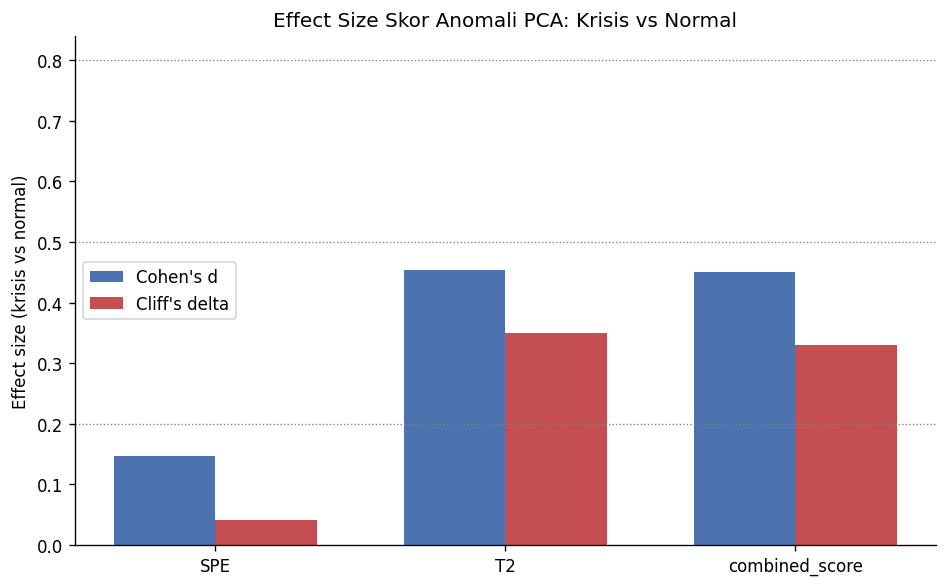

In [11]:

labels = effect_df["score"].tolist()
xpos = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xpos - w/2, effect_df["cohens_d"], w, label="Cohen's d", color=COLOR_NORMAL)
ax.bar(xpos + w/2, effect_df["cliffs_delta"], w, label="Cliff's delta", color=COLOR_CRISIS)
for thresh in (0.2, 0.5, 0.8):
    ax.axhline(thresh, color="gray", linestyle=":", linewidth=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel("Effect size (krisis vs normal)")
ax.set_title("Effect Size Skor Anomali PCA: Krisis vs Normal")
ax.legend()
fig.tight_layout()
plt.show()



## 10. Contribution Plot

Untuk observasi krisis yang terdeteksi sebagai anomali, kita hitung kontribusi tiap variabel
terhadap SPE (yaitu $(x_{ij} - \hat{x}_{ij})^2$ per variabel $j$) lalu dirata-ratakan. Ini
menjawab pertanyaan: **variabel makroekonomi mana yang paling "menyimpang" saat krisis
terdeteksi?**


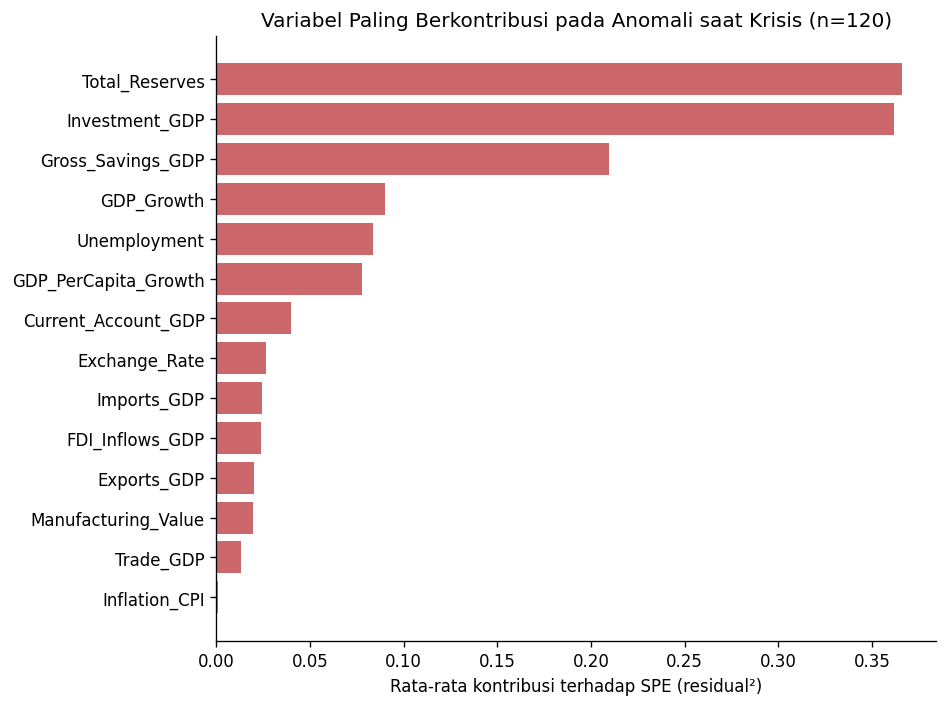

Total_Reserves          0.365813
Investment_GDP          0.361945
Gross_Savings_GDP       0.209449
GDP_Growth              0.089748
Unemployment            0.083479
GDP_PerCapita_Growth    0.077524
Current_Account_GDP     0.040063
Exchange_Rate           0.026615
Imports_GDP             0.024207
FDI_Inflows_GDP         0.023555
Exports_GDP             0.020118
Manufacturing_Value     0.019719
Trade_GDP               0.013196
Inflation_CPI           0.000590
dtype: float64

In [12]:

contrib = pd.DataFrame(residual_all ** 2, columns=FEATURE_COLS)
contrib["crisis_label"] = df["crisis_label"].values
contrib["is_anomaly_combined"] = df["is_anomaly_combined"].values

crisis_anom = contrib[(contrib["crisis_label"] == 1) & (contrib["is_anomaly_combined"] == 1)]
mean_contrib = crisis_anom[FEATURE_COLS].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.arange(len(mean_contrib)), mean_contrib.values, color=COLOR_CRISIS, alpha=0.85)
ax.set_yticks(np.arange(len(mean_contrib))); ax.set_yticklabels(mean_contrib.index)
ax.set_xlabel("Rata-rata kontribusi terhadap SPE (residual\u00b2)")
ax.set_title(f"Variabel Paling Berkontribusi pada Anomali saat Krisis (n={len(crisis_anom)})")
fig.tight_layout()
plt.show()

mean_contrib.sort_values(ascending=False)



## 11. Ringkasan dan Kesimpulan

**Ringkasan hasil (lihat `results/evaluation_metrics.csv` dan `results/effect_size.csv` untuk
angka lengkap):**

- PCA berhasil membangun profil "normalitas" makroekonomi hanya dari 1.385 observasi normal,
  kemudian men-*scoring* seluruh 1.714 observasi secara konsisten dengan cara algoritma lain
  (LOF) dievaluasi di kelompok ini.
- **T² (Hotelling) memberikan diskriminasi krisis-vs-normal yang lebih baik dibandingkan SPE**
  pada dataset ini (AUC-ROC dan effect size T² lebih tinggi) — artinya periode krisis di data ini
  lebih sering bermanifestasi sebagai kombinasi ekstrem *dalam* ruang komponen utama yang
  dipertahankan, bukan semata sebagai pola yang gagal direkonstruksi (SPE).
- Skor gabungan (`combined_score`, mengambil rasio maksimum terhadap UCL masing-masing
  statistik) memberikan keseimbangan Precision-Recall-F1 yang wajar untuk dipakai sebagai
  bagian dari EWS.
- Variabel dengan kontribusi rata-rata tertinggi terhadap anomali saat krisis dapat dipakai
  sebagai bahan interpretasi kebijakan (lihat contribution plot) — konsisten dengan keunggulan
  interpretabilitas PCA yang disebut dalam kajian literatur proposal (Yousfani et al., 2025).

**Keterbatasan:** UCL berbasis asumsi distribusi (chi-square approx. untuk SPE, F untuk T²)
dapat kurang presisi bila residual/skor PC tidak mendekati asumsi tersebut; effect size Cliff's
delta yang non-parametrik disertakan sebagai pembanding yang lebih robust terhadap pelanggaran
asumsi ini.
